# Proyecto Final | Predicción de Readmisión Hospitalaria
## Notebook 1 — Carga y Exploración de Datos (EDA)

**Dataset:** Diabetes 130-US Hospitals (1999–2008) — UCI ML Repository  
**Objetivo:** Predecir si un paciente diabético será **readmitido en menos de 30 días** tras el alta  
**Tipo de problema:** Clasificación binaria  

---
### Contexto clínico
La readmisión hospitalaria en menos de 30 días es un indicador clave de calidad asistencial y supone un alto coste para el sistema sanitario. Este dataset recoge 10 años de registros clínicos de pacientes diabéticos en 130 hospitales de EE.UU. El objetivo es identificar qué factores aumentan el riesgo de readmisión temprana para que los equipos médicos puedan intervenir de forma preventiva al alta.

## Tabla de Contenidos
1. [Importar librerías](#1)
2. [Cargar el dataset](#2)
3. [Exploración inicial](#3)
4. [Distribución del target](#4)
5. [Estadísticas descriptivas](#5)
6. [Análisis de valores faltantes](#6)
7. [Variables categóricas](#7)
8. [Variables numéricas](#8)
9. [Matriz de correlación](#9)
10. [Guardar datos limpios](#10)

## 1. Importar librerías <a id='1'></a>

In [29]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades
import os

# Configuración de visualización
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 55)

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Cargar el dataset <a id='2'></a>

**Diabetes 130-US Hospitals for years 1999–2008**  
Fuente: UCI Machine Learning Repository  

| Característica | Valor |
|----------------|-------|
| Muestras | 101.766 |
| Features | 49 (numéricas + categóricas) |
| Target | `readmitted` — NO / >30 / <30 |
| Período | 1999–2008 |
| Hospitales | 130 hospitales de EE.UU. |

In [30]:
url = 'https://raw.githubusercontent.com/14Richa/Patient-Readmission-Analysis/main/diabetic_data.csv'
df = pd.read_csv(url)

# Crear target binario: 1 = readmitido en <30 días, 0 = no readmitido en <30 días
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print('Dataset cargado correctamente')
print(f'   {df.shape[0]:,} pacientes | {df.shape[1]} columnas')
df.head()

Dataset cargado correctamente
   101,766 pacientes | 51 columnas


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


## 3. Exploración inicial <a id='3'></a>

In [31]:
# Dimensiones del dataset
print('=== SHAPE ===')
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

=== SHAPE ===
Filas:    101,766
Columnas: 51


In [32]:
# Tipos de datos — mezcla de numéricos y categóricos
print('=== TIPOS DE DATOS ===')
print(df.dtypes.value_counts())
print('\nDetalle:')
print(df.dtypes)

=== TIPOS DE DATOS ===
object    37
int64     14
Name: count, dtype: int64

Detalle:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateg

In [33]:
# Valores únicos por columna — detecta columnas ID y columnas con pocos valores
print('=== VALORES ÚNICOS POR COLUMNA ===')
for col in df.columns:
    print(f'{col:40s}: {df[col].nunique():>6} únicos')

=== VALORES ÚNICOS POR COLUMNA ===
encounter_id                            : 101766 únicos
patient_nbr                             :  71518 únicos
race                                    :      6 únicos
gender                                  :      3 únicos
age                                     :     10 únicos
weight                                  :     10 únicos
admission_type_id                       :      8 únicos
discharge_disposition_id                :     26 únicos
admission_source_id                     :     17 únicos
time_in_hospital                        :     14 únicos
payer_code                              :     18 únicos
medical_specialty                       :     73 únicos
num_lab_procedures                      :    118 únicos
num_procedures                          :      7 únicos
num_medications                         :     75 únicos
number_outpatient                       :     39 únicos
number_emergency                        :     33 únicos
number_inpati

## 4. Distribución del target <a id='4'></a>

El target original tiene 3 clases: `NO`, `>30`, `<30`.  
Lo convertimos a **binario**: `readmitted_30 = 1` si el paciente fue readmitido en menos de 30 días.

In [34]:
# Distribución del target original
print('=== TARGET ORIGINAL (3 clases) ===')
conteo_orig = df['readmitted'].value_counts()
pct_orig = df['readmitted'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Cantidad': conteo_orig, 'Porcentaje (%)': pct_orig}))

print('\n=== TARGET BINARIO (readmitido en <30 días) ===')
conteo = df['readmitted_30'].value_counts()
pct = df['readmitted_30'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': pct}))

=== TARGET ORIGINAL (3 clases) ===
            Cantidad  Porcentaje (%)
readmitted                          
NO             54864            53.9
>30            35545            34.9
<30            11357            11.2

=== TARGET BINARIO (readmitido en <30 días) ===
               Cantidad  Porcentaje (%)
readmitted_30                          
0                 90409            88.8
1                 11357            11.2


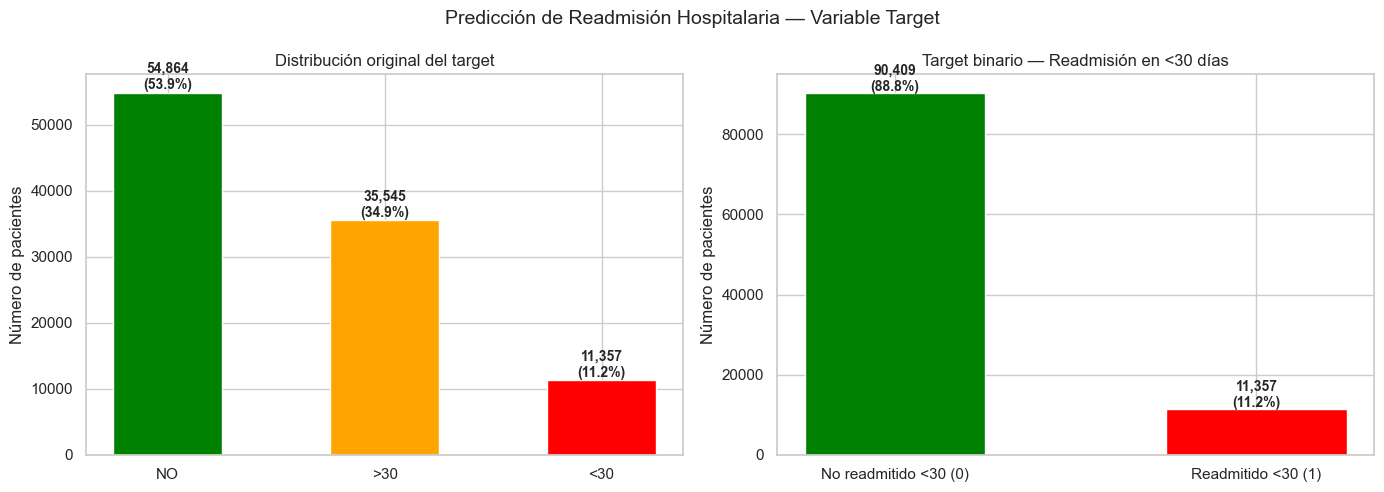

Dataset muy desbalanceado: solo ~11% de pacientes readmitidos en <30 días
→ Usaremos F1-score, ROC-AUC y Recall como métricas principales
→ Consideraremos class_weight="balanced" en los modelos


In [35]:
# Visualización del target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target original
conteo_orig = df['readmitted'].value_counts()
axes[0].bar(conteo_orig.index, conteo_orig.values,
            color=['green', 'orange', 'red'], edgecolor='white', width=0.5)
axes[0].set(title='Distribución original del target',
            ylabel='Número de pacientes')
for i, v in enumerate(conteo_orig.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)

# Target binario
conteo_bin = df['readmitted_30'].value_counts().sort_index()
labels = ['No readmitido <30 (0)', 'Readmitido <30 (1)']
axes[1].bar(labels, conteo_bin.values, color=['green', 'red'],
            edgecolor='white', width=0.5)
axes[1].set(title='Target binario — Readmisión en <30 días',
            ylabel='Número de pacientes')
for i, v in enumerate(conteo_bin.values):
    axes[1].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Predicción de Readmisión Hospitalaria — Variable Target', fontsize=14)
plt.tight_layout()
plt.show()

print('Dataset muy desbalanceado: solo ~11% de pacientes readmitidos en <30 días')
print('→ Usaremos F1-score, ROC-AUC y Recall como métricas principales')
print('→ Consideraremos class_weight="balanced" en los modelos')

## 5. Estadísticas descriptivas <a id='5'></a>

In [36]:
# Variables numéricas
print('=== ESTADÍSTICAS DE VARIABLES NUMÉRICAS ===')
df.select_dtypes(include='number').describe().round(2)

=== ESTADÍSTICAS DE VARIABLES NUMÉRICAS ===


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42,0.11
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93,0.31
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00,0.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00,0.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00,0.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00,1.00


In [37]:
# Comparar medias por target — nos ayuda a ver qué variables difieren entre clases
print('=== MEDIAS POR DIAGNÓSTICO (0=No readmitido / 1=Readmitido <30) ===')
df.groupby('readmitted_30').mean(numeric_only=True).round(2).T

=== MEDIAS POR DIAGNÓSTICO (0=No readmitido / 1=Readmitido <30) ===


readmitted_30,0,1
encounter_id,1.655115e+08,1.627347e+08
patient_nbr,5.422214e+07,5.519219e+07
admission_type_id,2.030000e+00,1.980000e+00
discharge_disposition_id,3.620000e+00,4.470000e+00
admission_source_id,5.750000e+00,5.820000e+00
time_in_hospital,4.350000e+00,4.770000e+00
num_lab_procedures,4.295000e+01,4.423000e+01
num_procedures,1.350000e+00,1.280000e+00
num_medications,1.591000e+01,1.690000e+01
number_outpatient,3.600000e-01,4.400000e-01


## 6. Análisis de valores faltantes <a id='6'></a>

Este dataset codifica los valores faltantes como `'?'` en lugar de `NaN`.  
Primero los convertimos para poder detectarlos correctamente.

In [38]:
# Reemplazar '?' por NaN para que pandas los reconozca como valores faltantes
df.replace('?', np.nan, inplace=True)

# Calcular número y porcentaje de nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(1)
nulos_df = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print('Columnas con valores faltantes:')
print(nulos_df)
print(f'\nTotal de celdas con NaN: {nulos.sum():,}')

Columnas con valores faltantes:
                   Nulos  % Nulos
weight             98569     96.9
max_glu_serum      96420     94.7
A1Cresult          84748     83.3
medical_specialty  49949     49.1
payer_code         40256     39.6
race                2273      2.2
diag_3              1423      1.4
diag_2               358      0.4
diag_1                21      0.0

Total de celdas con NaN: 374,017


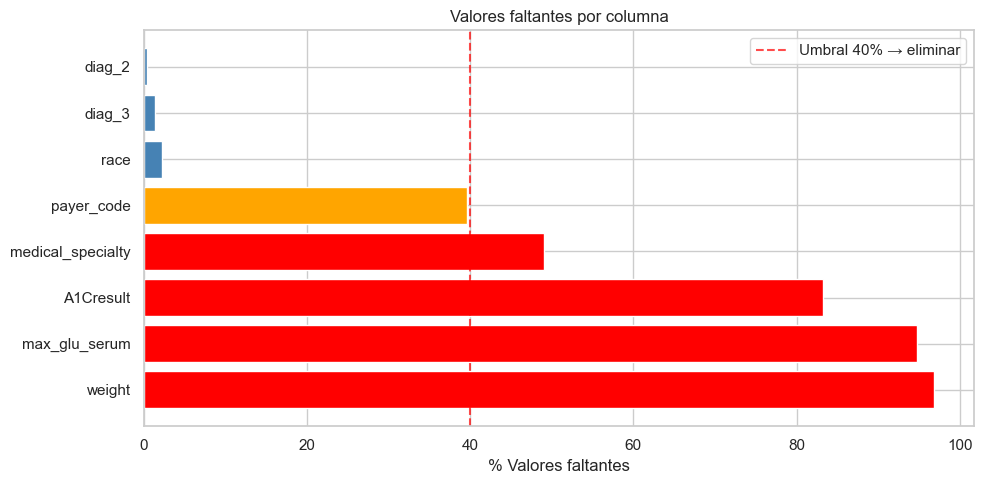


Columnas a eliminar (>40% nulos): ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']
→ Se tratarán en el Notebook 2


In [39]:
# Visualización de nulos — coloreamos según severidad
nulos_plot = nulos_df[nulos_df['% Nulos'] > 0]

plt.figure(figsize=(10, 5))
bars = plt.barh(nulos_plot.index, nulos_plot['% Nulos'],
                color=['red' if v > 40 else 'orange' if v > 10 else 'steelblue'
                       for v in nulos_plot['% Nulos']])
plt.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='Umbral 40% → eliminar')
plt.xlabel('% Valores faltantes')
plt.title('Valores faltantes por columna')
plt.legend()
plt.tight_layout()
plt.show()

cols_eliminar = nulos_df[nulos_df['% Nulos'] > 40].index.tolist()
print(f'\nColumnas a eliminar (>40% nulos): {cols_eliminar}')
print('→ Se tratarán en el Notebook 2')

## 7. Variables categóricas <a id='7'></a>

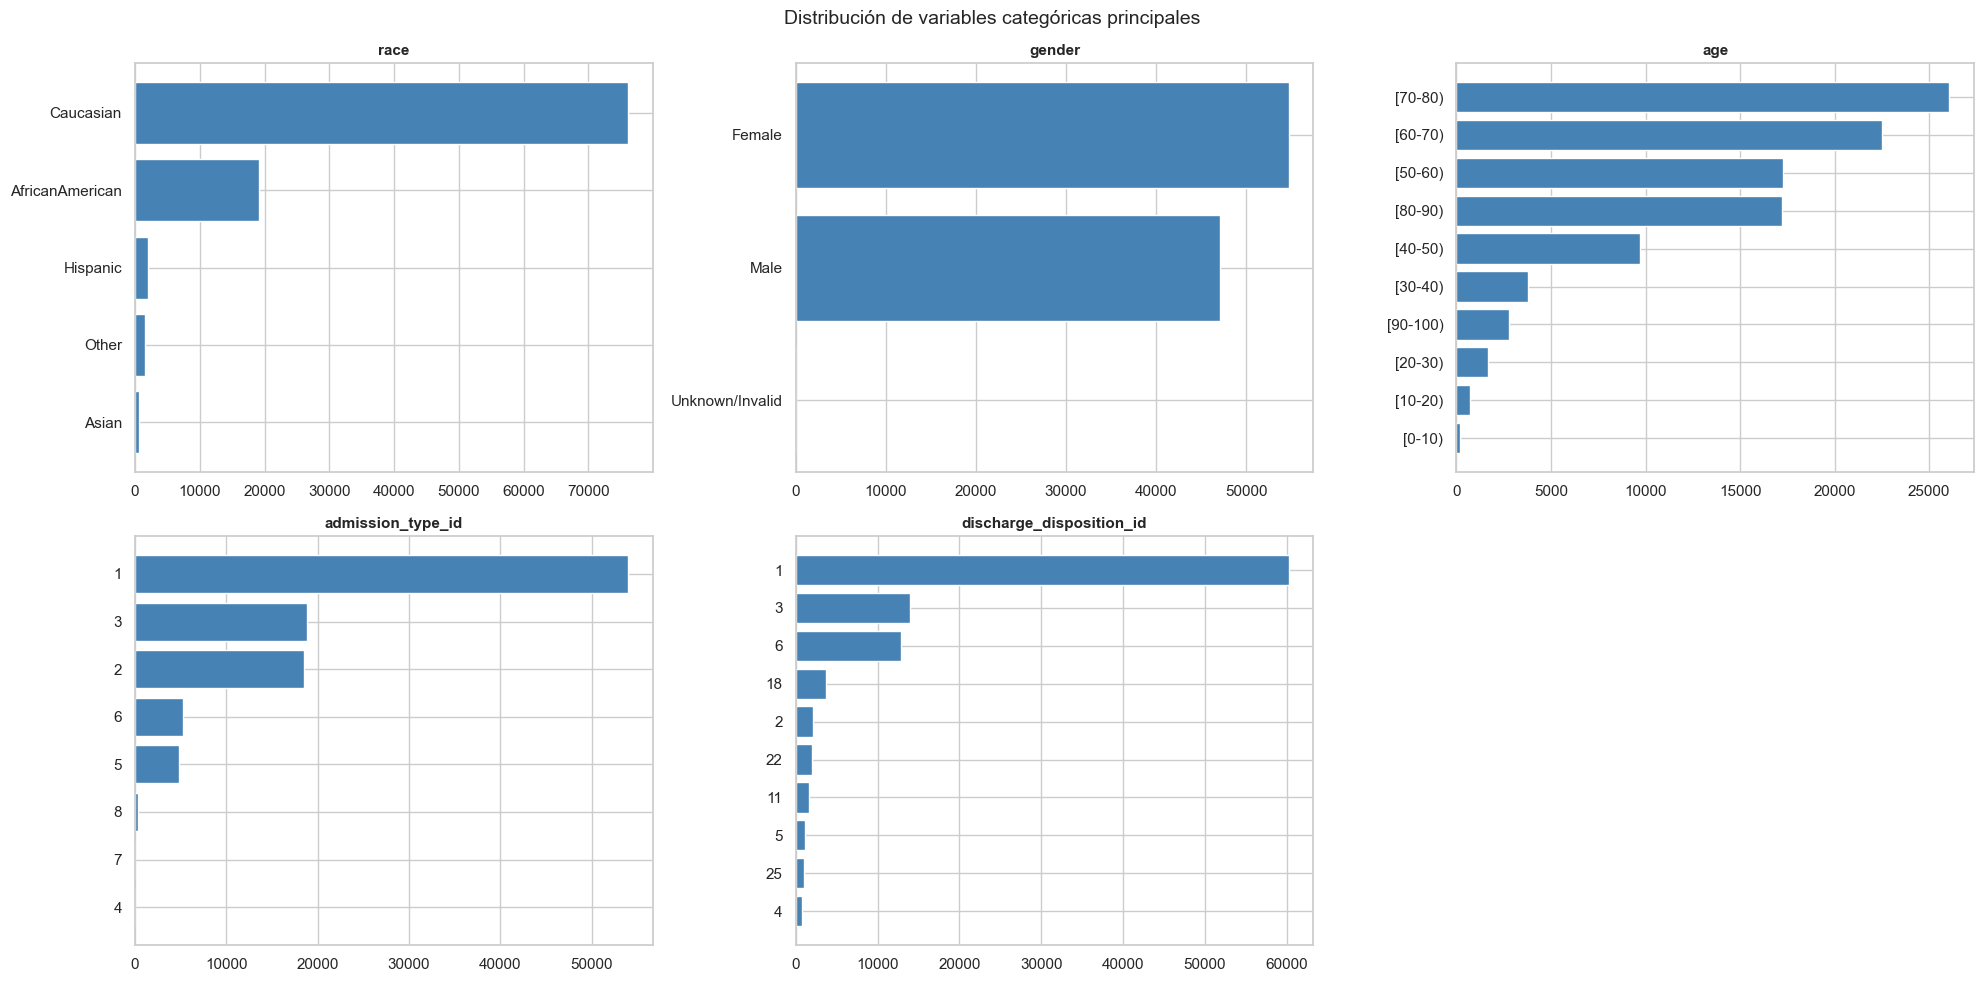

In [40]:
# Distribución de las principales variables categóricas
cat_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    conteo = df[col].value_counts().head(10)
    axes[i].barh(conteo.index.astype(str)[::-1], conteo.values[::-1],
                 color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')

axes[5].axis('off')
plt.suptitle('Distribución de variables categóricas principales', fontsize=14)
plt.tight_layout()
plt.show()

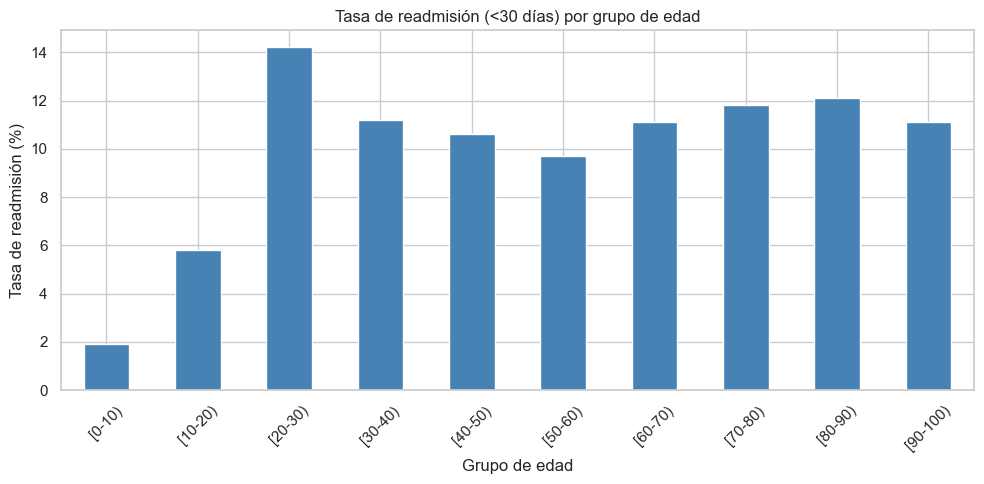

In [41]:
# Tasa de readmisión por grupo de edad
tasa_edad = df.groupby('age')['readmitted_30'].mean().sort_index().mul(100).round(1)

plt.figure(figsize=(10, 5))
tasa_edad.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Tasa de readmisión (<30 días) por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de readmisión (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Variables numéricas <a id='8'></a>

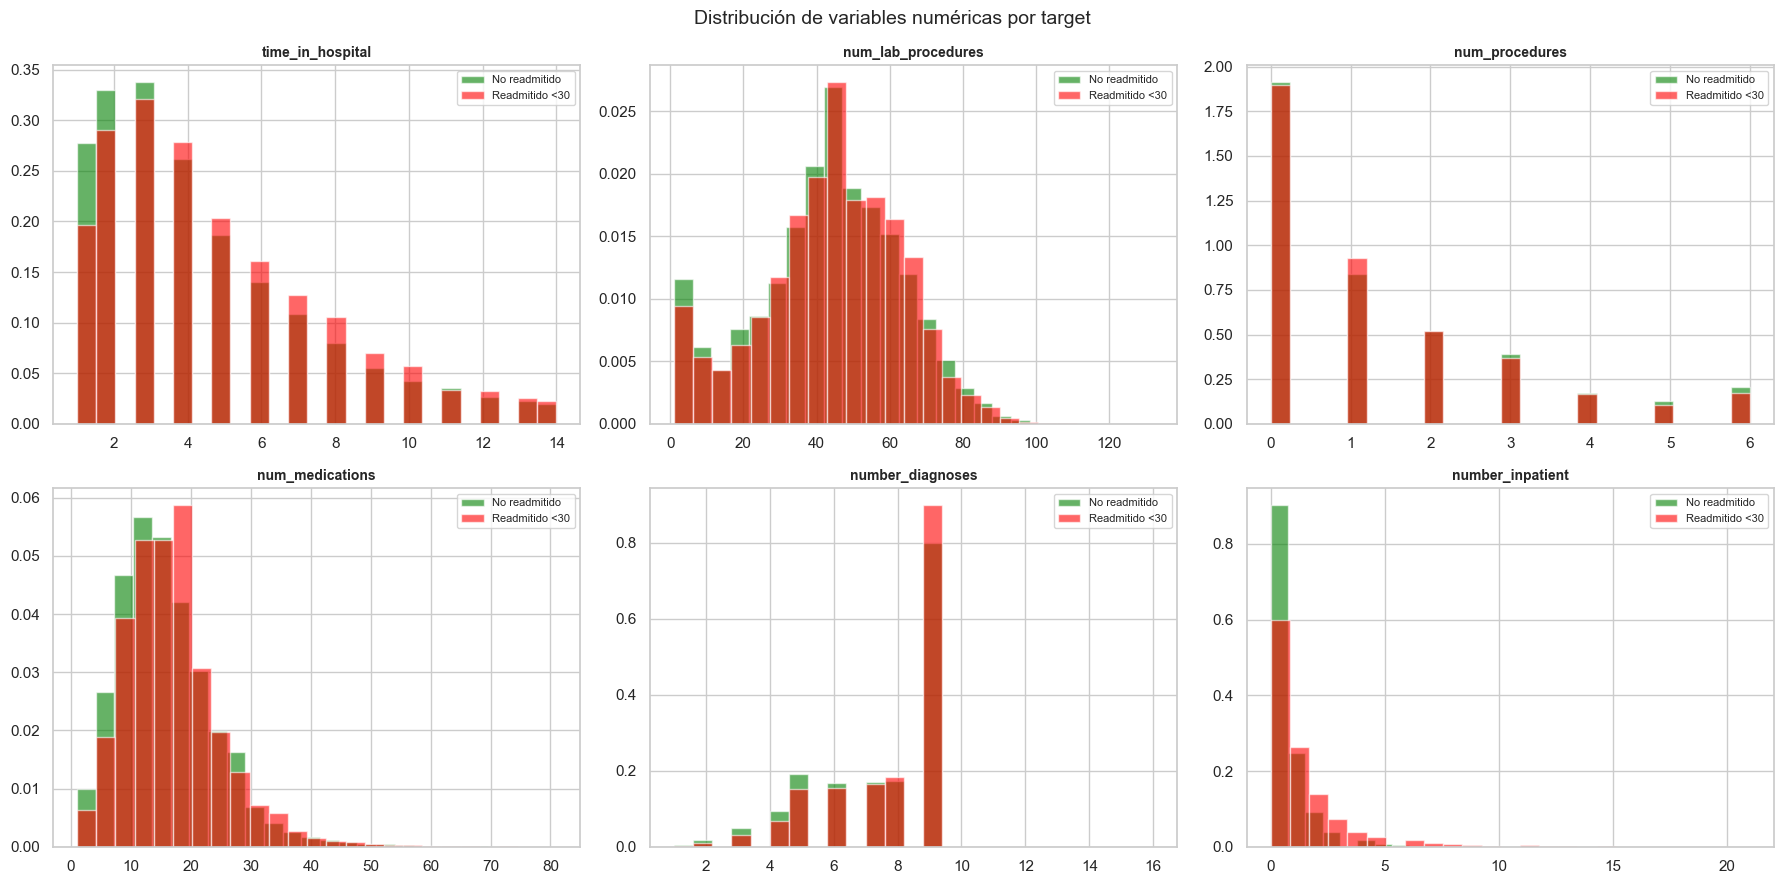

In [42]:
# Histogramas de variables numéricas por target
# Nos ayuda a ver si las distribuciones difieren entre clases
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_inpatient']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for val, color, label in zip([0, 1], ['green', 'red'],
                                  ['No readmitido', 'Readmitido <30']):
        axes[i].hist(df[df['readmitted_30'] == val][col].dropna(),
                     bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas por target', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Matriz de correlación <a id='9'></a>

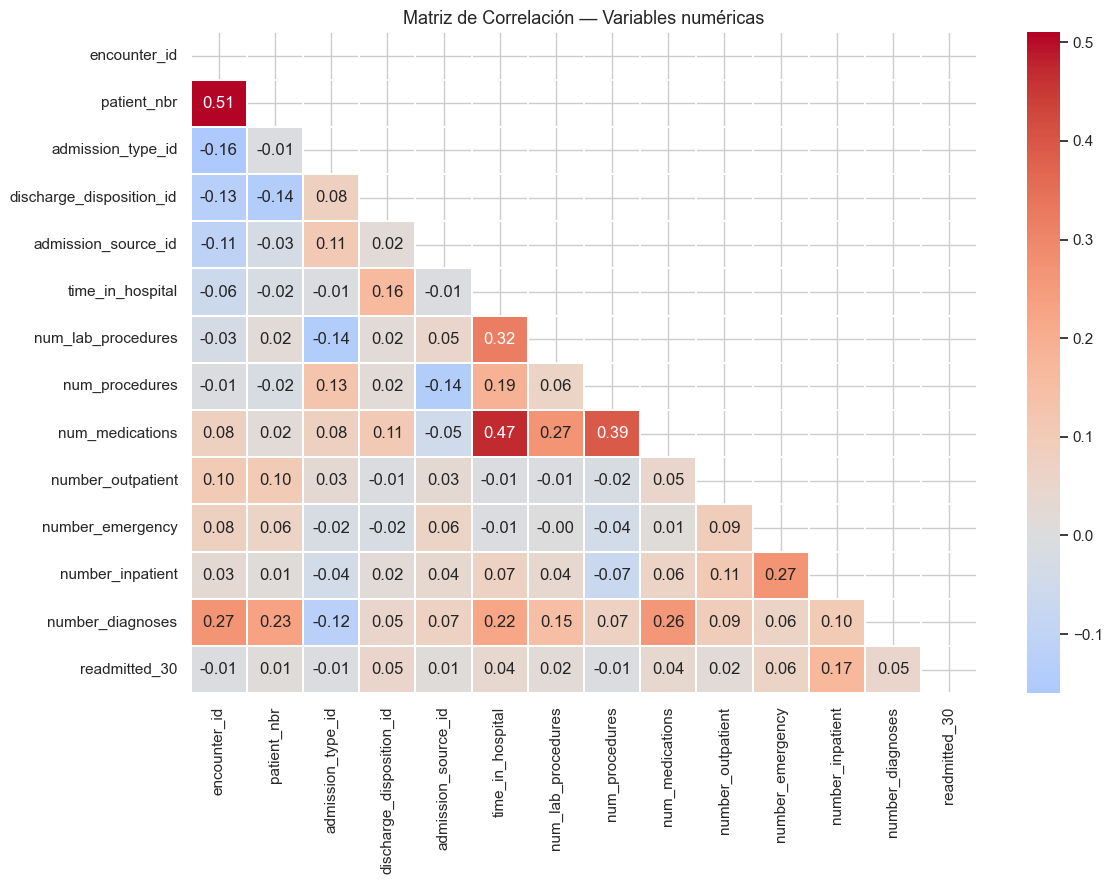

In [43]:
# Correlación entre variables numéricas
num_df = df.select_dtypes(include='number')
corr = num_df.corr().round(2)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.3)
plt.title('Matriz de Correlación — Variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

In [44]:
# Top features más correlacionadas con el target
corr_target = corr['readmitted_30'].drop('readmitted_30').abs().sort_values(ascending=False)

print('Top features numéricas correlacionadas con readmitted_30:')
print(corr_target.head(10).round(3).to_string())

Top features numéricas correlacionadas con readmitted_30:
number_inpatient            0.17
number_emergency            0.06
number_diagnoses            0.05
discharge_disposition_id    0.05
time_in_hospital            0.04
num_medications             0.04
num_lab_procedures          0.02
number_outpatient           0.02
encounter_id                0.01
admission_source_id         0.01


## 10. Guardar datos limpios <a id='10'></a>

In [45]:
# Guardamos el dataset con los '?' ya convertidos a NaN para usarlo en el Notebook 2
os.makedirs('data', exist_ok=True)
df.to_csv('data/readmision_raw.csv', index=False)

print('Dataset guardado en data/readmision_raw.csv')
print(f'Shape: {df.shape}')
print(f'Valores nulos: {df.isnull().sum().sum():,}')

Dataset guardado en data/readmision_raw.csv
Shape: (101766, 51)
Valores nulos: 374,017


---
## Resumen del Notebook 1

| Aspecto | Resultado |
|---------|----------|
| **Muestras** | 101.766 pacientes |
| **Features** | 49 (numéricas + categóricas) |
| **Target** | Readmisión en <30 días (binario) |
| **Balance** | Muy desbalanceado — 11% positivos |
| **Valores nulos** | Codificados como `?` → convertidos a NaN |
| **Columnas a eliminar** | `weight`, `payer_code`, `medical_specialty` (>40% nulos) |
| **Encoding necesario** | Sí — múltiples variables categóricas |
| **Normalización** | Sí — rangos distintos entre features numéricas |
| **Métrica prioritaria** | ROC-AUC + Recall (clase positiva) |

---